# Тема 2. Моделирование связи частотного и классического определения вероятности
Приведите пример, показывающий связь частотного и классического определения вероятности с помощью моделирования (на примере задачи про красно-синие шары или задачи о сумме очков на двух кубиках). Графически показать стремление частотной вероятности к классической при увеличении числа опытов.

> Задача: В биологической лаборатории изучается скрещивание двух гибридных растений гороха. Согласно законам генетики (второму закону Менделя), классическая вероятность появления плода с рецессивным признаком (зеленый цвет семян) составляет $(P(aa) = 0.25)$. Биологи провели серию опытов и вырастили N растений. В ходе эксперимента фиксировалось общее число появившихся зеленых горошин m и рассчитывалась их относительная частота: $W = \frac{m}{N}$.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
ls = ['Желтый', 'Зеленый']

prob = {'Желтый': 0.75, 'Зеленый': 0.25}

for outcome, p in prob.items():
    print(f'Признак "{outcome}", классическая вероятность: {p}.')

Признак "Желтый", классическая вероятность: 0.75.
Признак "Зеленый", классическая вероятность: 0.25.


In [46]:
N = 1000

np.random.seed(42)

experiments = np.random.choice(['Желтый', 'Зеленый'], p=[0.75, 0.25], size=N)

freq = {'Желтый': (experiments == 'Желтый').sum()/N, 'Зеленый': (experiments == 'Зеленый').sum()/N}

for outcome in freq.keys():
    print(f'Признак "{outcome}", итоговая частота: {freq[outcome]:.4f}')

Признак "Желтый", итоговая частота: 0.7570
Признак "Зеленый", итоговая частота: 0.2430


In [47]:
frequency = [freq[outcome] for outcome in prob.keys()]
df = pd.DataFrame(index=prob.keys(),
                  data={'Вероятность': prob.values(),
                        'Частота': frequency})
df['Отклонение'] = abs(df['Вероятность'] - df['Частота'])
df

,Вероятность,Частота,Отклонение
Желтый,0.75,0.757,0.007
Зеленый,0.25,0.243,0.007


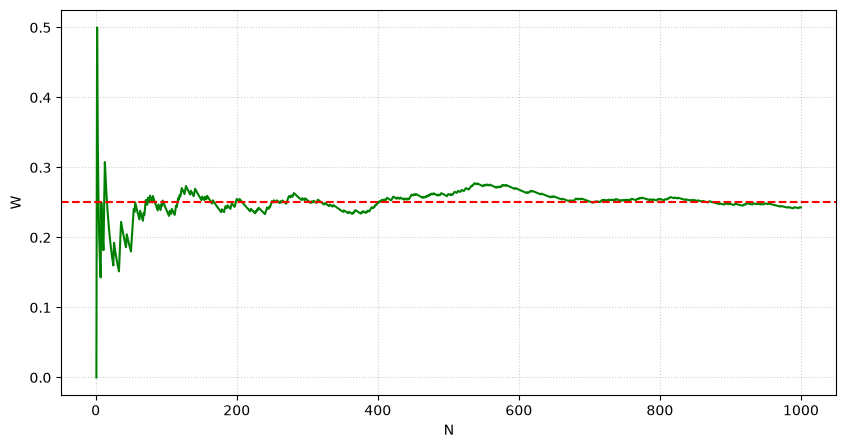

In [48]:
green_counts = np.cumsum([1 if res == 'Зеленый' else 0 for res in experiments])
trials = np.arange(1, N + 1)
frequencies = green_counts / trials

plt.figure(figsize=(10, 5))
plt.plot(trials, frequencies, color='green')
plt.axhline(y=0.25, color='red', linestyle='--')

plt.xlabel('N')
plt.ylabel('W')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
